In [2]:
import numpy as np
from dtreeviz.trees import dtreeviz
from sklearn.datasets import load_boston,load_iris,load_digits,fetch_california_housing,fetch_openml
from sklearn.metrics import accuracy_score,mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor,plot_tree
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
class Noeud():
    def __init__(self,X,y,depth,classes,critere="gini",feuille=False):
        self.feuille = feuille
        self.X = X
        self.y = y
        self.depth = depth
        self.classes = classes
        self.n1 = None
        self.n2 = None
        self.critere = critere
        self.featureIndex = None
        self.tv = None
        self.isClassification = critere in ['gini','entropy']

    def setFeuille(self):
        self.feuille = True
    def setTest(self,featureIndex,tv,quali):
        self.featureIndex = featureIndex
        self.tv = tv
        self.isQualitatif = quali
        
    def setFeuilleGauche(self,n):
        self.n1 = n
    def setFeuilleDroite(self,n):
        self.n2 = n

    def isFeuille(self):
        return self.feuille or self.getPurete() == 0
    def getPlusFrequent(self):
        from collections import Counter
        return Counter(self.y).most_common(1)[0][0]

    # la moyenne des valeurs da la cible
    def getMoy(self):
        return self.y.mean()

    # predire la valeur de la cible de donnée "pre"
    def getPrediction(self,pre):
        # si le noeud est une feuille on donne la valeur de getPlusFrequent ou la mpoyenne (getMoy)
        if self.n1 is None or self.n2 is None:
            if self.isClassification:
                return self.getPlusFrequent()
            else:
                return self.getMoy()
        # sinon, on decide si le noeud fils qui va donner la prediction ou le droit
        f = pre[self.featureIndex]
        if self.isQualitatif:
            return self.n1.getPrediction(pre) if f == self.tv else self.n2.getPrediction(pre)
        else:
            return self.n1.getPrediction(pre) if f <= self.tv else self.n2.getPrediction(pre)
    # la pureté d'un noeud selon la critère
    def getPurete(self):
        if self.critere == 'gini':
            return self.gini()
        elif self.critere == 'entropy':
            return self.entropy()
        elif self.critere == 'squared_error':   
            return self.squared_error()
    # critère "squared_error" de type regression
    def squared_error(self):
        return ((self.y - self.y.mean())**2).sum() / self.y.size
    # critère "entropy" de type classification
    def entropy(self):
        occu = self.getOcuu()
        p = []
        for i in occu:
            if i!=0:
                p.append(i)
        p = np.array(p)
        p = (p / p.sum())
        a = p * np.log(p)
        return -1 * a.sum()
    # critère "gini" de type classification
    def gini(self):
        occu = self.getOcuu()
        p = (occu / occu.sum())
        a = p * (1 - p)
        return a.sum()

    def getSum(self):
        return self.X.shape[0]
    # les occurences des classes de la cible dans ce noeud
    def getOcuu(self):
        a = [int(i) for i in self.y]
        a = np.bincount(a)
        occu = [(a[i] if i < a.size else 0) for i in self.classes]
        return np.array(occu)
    # afficher des informations de ce noeud dans une manière hiérarchique
    def print(self):
        a = ""
        if self.featureIndex is not None and self.tv is not None:
            a = "==" if self.isQualitatif else "<="
            a = "X[%d] %s %.2f" % (self.featureIndex,a,self.tv)
        print(self.depth * "\t",
              self.getOcuu() if self.isClassification else "",
              "samples:",self.getSum(),
              a,
              self.critere+":",self.getPurete())
        if self.n1 is not None:
            self.n1.print()
        if self.n2 is not None:
            self.n2.print()
            
    # clacule de cost on fonction des deux noeud fils
    def getCost(self):
        sum1,p1 = self.n1.getSum(),self.n1.getPurete()
        sum2,p2 = self.n2.getSum(),self.n2.getPurete()
        res = (sum1 * p1 + sum2 * p2) / (sum1 + sum2)
        # print(sum1,p1,sum2,p2)
        return res


In [4]:

class DecisionTree():

    _class_criteres = ['gini','entropy']
    _regr_criteres = ['squared_error']
    _tous_criteres = ['gini','entropy','squared_error']

    def __init__(self,X,y,maxDepth=None,critere='gini'):
        
        self.maxDepth = maxDepth
        self.X = X
        self.y = y
        
        if critere not in DecisionTree._tous_criteres:
            raise Exception("critere invalid")
        self.isClassification = critere in DecisionTree._class_criteres
        self.critere = critere
        self.classes = np.unique(y) if self.isClassification else None
    # fonction d'entrainement
    def entrainer(self):
        self.racine = Noeud(self.X,self.y,0,classes=self.classes,critere=self.critere)
        return self._entrainer(self.racine)
    def _entrainer(self,noeud:Noeud):
        test_valeurs,droite,gauche = None,None,None
        
        puretes = []

        if (self.maxDepth is not None and noeud.depth >= self.maxDepth) or (noeud.isFeuille()):
            return
            
        pur = noeud.getPurete()
        for i in range(noeud.X.shape[1]):
            feature = noeud.X[:,i]
            isQualitatif = len(np.unique(feature)) <= 5
            if isQualitatif:
                test_valeurs = np.unique(feature)
            else:
                sorted = np.sort(feature,axis=0)
                test_valeurs = (sorted[1:] + sorted[:-1])/2
            for tv in test_valeurs:
                if self.split(noeud,feature,tv,isQualitatif) != False:
                    c = noeud.getCost()
                    if self.isClassification:
                        puretes.append([c,i,tv])
                    else:
                        if c < pur:
                            puretes.append([c,i,tv])
        noeud.setFeuilleGauche(None)
        noeud.setFeuilleDroite(None)
        if len(puretes) == 0:
            return
        puretes = np.array(puretes)
        min_ = puretes[:,0].argmin()
        c,i,tv = puretes[min_]
        i = int(i)
        
        feature = noeud.X[:,i]
        isQualitatif = len(np.unique(feature)) <= 5
        self.split(noeud,feature,tv,isQualitatif)
        noeud.setTest(i,tv,isQualitatif)
        self._entrainer(noeud.n1)
        self._entrainer(noeud.n2)
    # affichage d'arbre
    def print(self):
        self.racine.print()
    # predire la classe d'une ou plusieurs données
    def predict(self,pre):
        pre = np.array(pre)
        if pre.ndim == 2:
            return np.array([self.racine.getPrediction(i) for i in pre])
        elif pre.ndim == 1:
            return self.racine.getPrediction(pre)
    # diviser le jeu de données en deux parties en fonction de feature et tv 
    def split(self,noeud,feature,tv,isQualitatif):
        id_gauche = None
        id_droite = None
        if isQualitatif:
            gauche = noeud.X[feature == tv]
            droite = noeud.X[feature != tv]
            id_gauche = np.where(feature == tv)
            id_droite = np.where(feature != tv)
        else:
            gauche = noeud.X[feature <= tv]
            droite = noeud.X[feature > tv]
            id_gauche = np.where(feature <= tv)
            id_droite = np.where(feature > tv)
        id_gauche,id_droite = id_gauche[0],id_droite[0]
        if id_gauche.size == 0 or id_droite.size == 0:
            return False
        noeud.setFeuilleGauche(Noeud(gauche,noeud.y[id_gauche],noeud.depth+1,classes=self.classes,critere=noeud.critere))
        noeud.setFeuilleDroite(Noeud(droite,noeud.y[id_droite],noeud.depth+1,classes=self.classes,critere=noeud.critere))

In [5]:
def mal_predit(yreal,ypred):
    return np.nonzero(yreal-ypred)[0].size / yreal.size * 100

In [16]:
def test(critere,
        max_depth,
        func,
        Tree,
        size=None):
    dataset = func()
    size = None if size is None else min(size,dataset.target.size)
    data = dataset.data if size is None else dataset.data[:size]
    target = dataset.target if size is None else dataset.target[:size]
    X_train, X_test, y_train, y_test = train_test_split(data,target,test_size=0.3)
    tree = DecisionTree(X_train,y_train,maxDepth=max_depth,critere=critere)
    tree.entrainer()
    sk_tree = Tree(max_depth=max_depth,criterion=critere)
    sk_tree.fit(X_train,y_train)
    return dataset,tree,sk_tree,X_train, X_test, y_train, y_test
def test_classification(critere="gini",max_depth=2,func=load_iris,size=1000):
    dataset,tree,sk_tree,X_train, X_test, y_train, y_test = test(critere,max_depth,
                                                           func,
                                                           DecisionTreeClassifier,
                                                           size = size)
    print_score(sk_tree,tree,X_train,y_train,"train")
    print("-------------------------------------")
    print_score(sk_tree,tree,X_test,y_test,"test")


    return dataset,tree,sk_tree,X_train, X_test, y_train, y_test


def test_regression(critere="squared_error",max_depth=2,func=load_boston,size=1000):
    dataset,tree,sk_tree,X_train, X_test, y_train, y_test = test(critere,
                                                           max_depth,
                                                           func,
                                                           DecisionTreeRegressor,
                                                           size = size)
    
    print_error(sk_tree,tree,X_train,y_train,"train")
    print("-------------------------------------")
    print_error(sk_tree,tree,X_test,y_test,"test")


    return dataset,tree,sk_tree,X_train, X_test, y_train, y_test
    
def print_score(sk_tree,tree,X,y,type):
    print("Sklearn",type,"accuracy score: ",accuracy_score(y,sk_tree.predict(X)))
    print("Notre Methode",type,"accuracy score",accuracy_score(y,tree.predict(X)))
    
def print_error(sk_tree,tree,X,y,type):
    print("Sklearn",type,"error score: ",mean_squared_error(y,sk_tree.predict(X)))
    print("Notre Methode",type,"error score",mean_squared_error(y,tree.predict(X)))

In [32]:
res = test_regression(critere="squared_error",
                          max_depth=3,
                          size=1000,)
dataset,tree,sk_tree,X_train, X_test, y_train, y_test = res

C:\Users\PiCi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function load_boston is deprecated; `load_boston` is deprecated in 1.0 and will be removed in 1.2.

    The Boston housing prices dataset has an ethical problem. You can refer to
    the documentation of this function for further details.

    The scikit-learn maintainers therefore strongly discourage the use of this
    dataset unless the purpose of the code is to study and educate about
    ethical issues in data science and machine learning.

    In this special case, you can fetch the dataset from the original
    source::

        import pandas as pd
        import numpy as np


        data_url = "http://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

    Alternative datasets include the

Sklearn train error score:  16.070080845017124
Notre Methode train error score 16.070080845017124
-------------------------------------
Sklearn test error score:  22.500895623156165
Notre Methode test error score 22.500895623156172


In [33]:
tree.print()

  samples: 354 X[12] <= 9.76 squared_error: 84.63090842350537
	  samples: 144 X[5] <= 7.44 squared_error: 79.5070061728395
		  samples: 126 X[5] <= 6.63 squared_error: 39.80848072562358
			  samples: 75  squared_error: 29.125450666666662
			  samples: 51  squared_error: 23.83333333333333
		  samples: 18 X[10] <= 14.70 squared_error: 15.570617283950615
			  samples: 9  squared_error: 4.639999999999998
			  samples: 9  squared_error: 17.866913580246905
	  samples: 210 X[12] <= 19.23 squared_error: 23.455039455782313
		  samples: 150 X[12] <= 14.40 squared_error: 13.81697288888889
			  samples: 78  squared_error: 9.001203155818539
			  samples: 72  squared_error: 11.513007330246914
		  samples: 60 X[4] <= 0.60 squared_error: 15.845430555555556
			  samples: 17  squared_error: 9.555363321799305
			  samples: 43  squared_error: 9.13641968631693


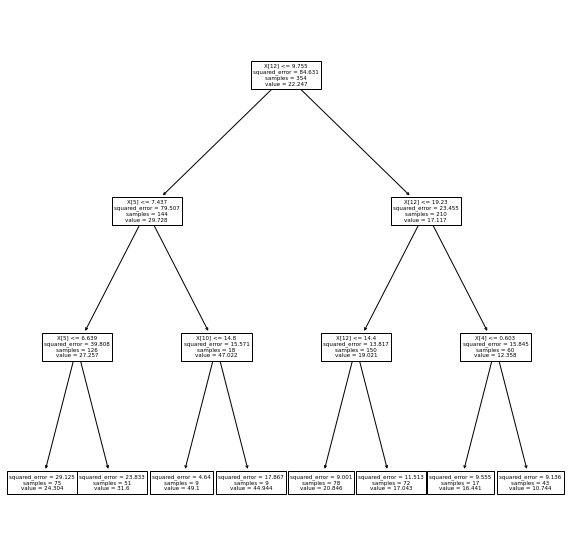

In [34]:
plt.figure(figsize=(10,10))
plot_tree(sk_tree,impurity=True)
plt.show()

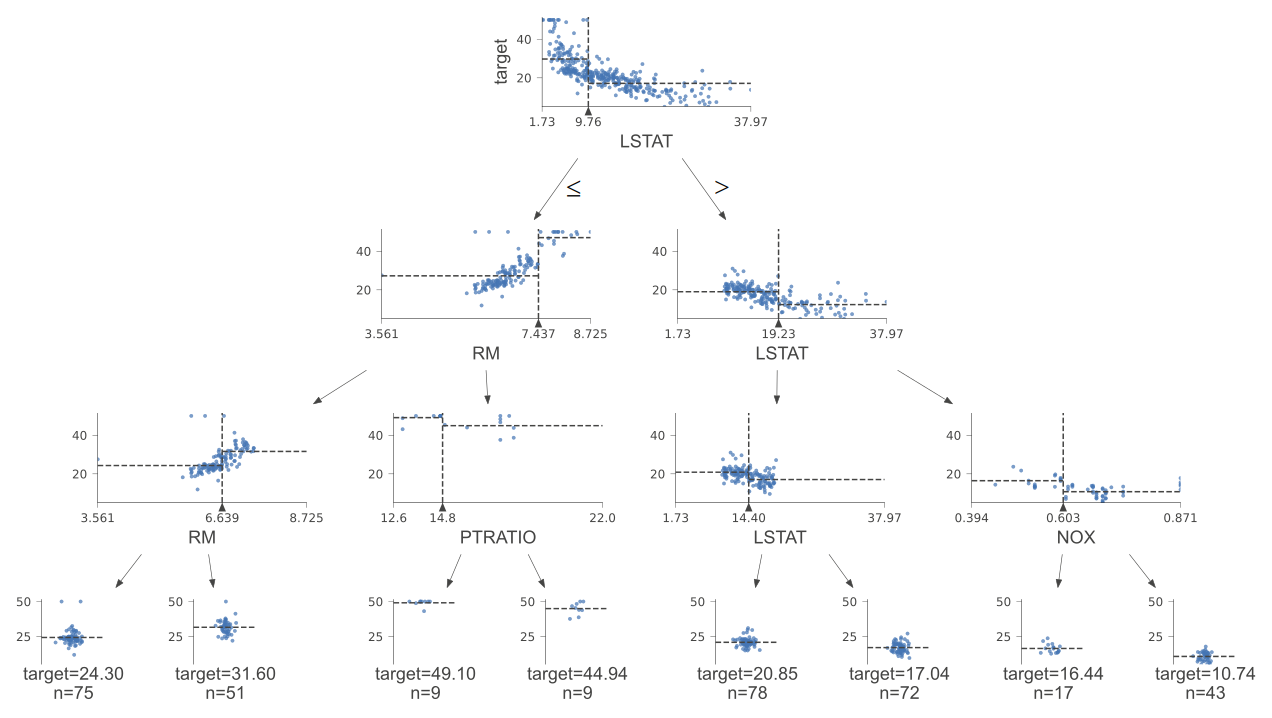

In [35]:
classes = getattr(dataset,'target_names',None)
classes = getattr(dataset,'target_name',None) if classes is None else classes
classes = "prix" if classes is None else classes
viz = dtreeviz(sk_tree, 
               X_train,
               y_train,
               target_name="target",
               feature_names=dataset.feature_names,
               class_names=list(classes),
               scale=2)
viz